### My Two Cents
![goodfellas](https://media1.tenor.com/m/k0sKgPEI2bsAAAAC/mob-gangster.gif)

I was born in New York City... well techincally NYC: I was born on Staten Island, the most suburban of the five boroughs, and I lived there for the first decade of my life. Fun fact: some of the movie *Goodfellas* was shot there; I could point out where those scenes were shot on a map.

There, I enjoyed lots of things: a well-maintained public transit system, good food, and I lived in close proximity to the *actual* city.  

But a few months after the start of my fourth grade year, I moved to New Jersey. And then I quickly realized something that I took for granted...

***There were no playgrounds!***

If I wanted to go to a playground, I would have had to ask for my mom to drive me because there weren't many around!

When I lived in the city, I remember being much happier because there were playgrounds all over, well within walking distance... but since I moved to NJ, I remember being home almost all the time because there really wasn't anywhere for me to go outside and play.

### How will we crown a winner?

As defined in our  master notebook, the calculations here are a part of a 3-part subscore ranging from $0 \le n \le 1$, or in normal human language, the subscore is a decimal between 0 and 1. For this subscore, the higher the score, the better; the more playgrounds, the higher the subscore, and thus the better subscore.

With that out of the way, **let's get to crunching some numbers.**

My dataset is a list of playgrounds within the City of Pittsburgh. So let's define that in my code and import Pandas while we're at it and see what it looks like.

In [1]:
import pandas as pd
pg = pd.read_csv("playgrounds.csv", sep=",")

print(pg.head)

<bound method NDFrame.head of      _id          id                          name  type  \
0      1   731501774          Able Long Playground   NaN   
1      2  1461276747      Albert Graham Playground   NaN   
2      3  1860709784             Alpine Playground   NaN   
3      4  1770671485              Alton Playground   NaN   
4      5    18942817              Ammon Playground   NaN   
..   ...         ...                           ...   ...   
120  121  1199980206     Phillips Lower Playground   NaN   
121  122  2108783707        Duncan Park Playground   NaN   
122  123   675610013     McKinley Upper Playground   NaN   
123  155  1683700344      Liberty Green Playground   NaN   
124  188   311422075  Spring Garden Ave Playground   NaN   

    maintenance_responsibility                     park             street  \
0              Parks - Western           Able Long Park          COAST AVE   
1             Parks - Schenley  Albert Turk Graham Park        FORESIDE PL   
2             P

![charlie brown](https://media1.tenor.com/m/XWGtWafRWzEAAAAC/charlie-brown-good-grief.gif)

That's too much information... let me make that more digestable for you.

I'll only show the most important data (for the time being): the name of the playground and the Neighborhood you can find it in. 

In [2]:
subset = pg[['name', 'neighborhood']]

print(subset.head())

                       name       neighborhood
0      Able Long Playground          Beechview
1  Albert Graham Playground   Crawford-Roberts
2         Alpine Playground  Central Northside
3          Alton Playground          Beechview
4          Ammon Playground  Bedford Dwellings


![spunch bob](https://media1.tenor.com/m/NbbbppVqVx8AAAAC/spongebob-swag.gif)

Much better! Now let's count how many of these playgrounds are in the same neighborhood... and for good measure, figure out how long this list is.

In [3]:
count = pg.groupby("neighborhood").size().reset_index(name = "playground_count")
count = count.sort_values("playground_count", ascending = False)
print(count.head())
print("The length is " + str(count.size))

           neighborhood  playground_count
56  Squirrel Hill South                 8
4             Beechview                 5
52    South Side Slopes                 5
0      Allegheny Center                 4
29        Highland Park                 4
The length is 136


That's a lot of neighborhoods! 

Let's get fancy and turn that into a chart... or at least the top 10.

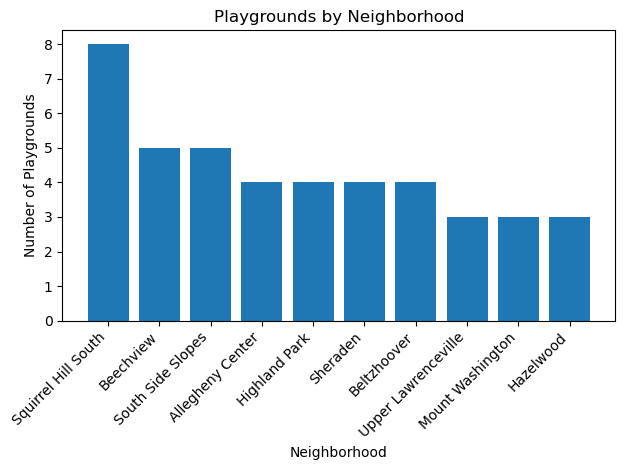

In [4]:
import matplotlib.pyplot as plt

top10 = count.head(10)

plt.bar(top10["neighborhood"], top10["playground_count"])
plt.xticks(rotation = 45, ha = "right")
plt.xlabel("Neighborhood")
plt.ylabel("Number of Playgrounds")
plt.title("Playgrounds by Neighborhood")
plt.tight_layout()
plt.show()

![how it feels to use matplotlib](https://media1.tenor.com/m/yOKTxh5m2lIAAAAd/tesla-and-einstein-luma-ai.gif)

Great Scott! We have a visualization of my data!

Now let's see how ***EVERY*** neighborhood compares. Be forewarned: you'll want your glasses for this one.

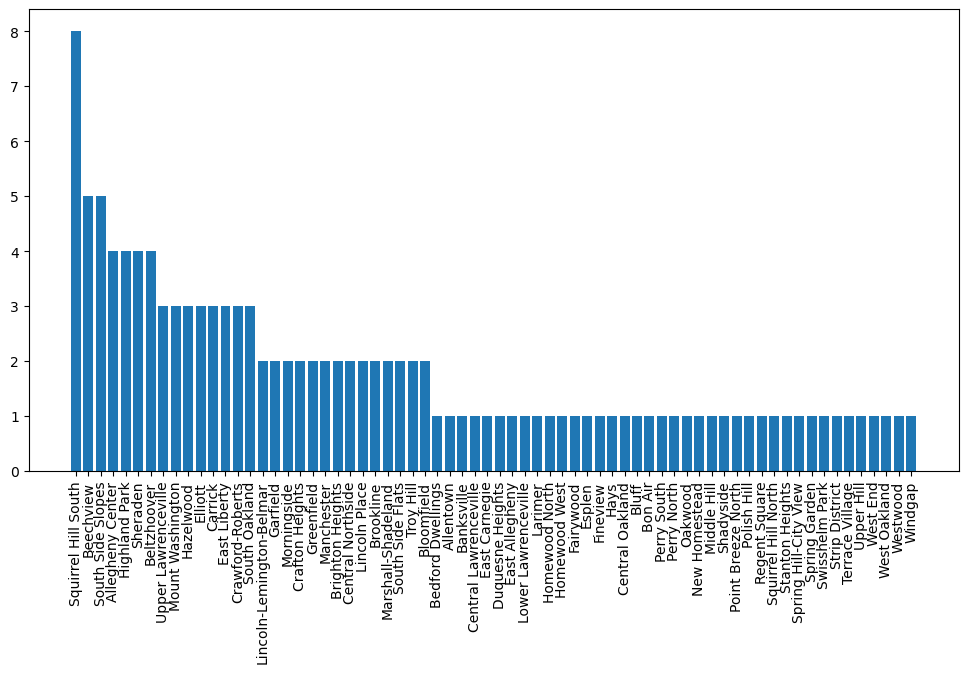

In [7]:
plt.figure(figsize=(12,6))
plt.bar(count["neighborhood"], count["playground_count"])
plt.xticks(rotation=90)
plt.show()

Let's throw out another visual while we're at it. I went to [Google My Maps](https://www.google.com/maps/d/u/1/edit?mid=1uZje1pOzDm_lGC8x7sGFMyuYCmEjzRo&usp=sharing) to visualize this data and confirm that Squirrel Hill South has the most playgrounds. The crossed out pins are **not** in Squirrel Hill South. *Apologies for my chicken scratch.*

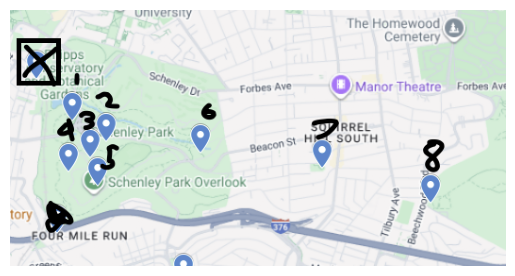

In [8]:
import matplotlib.image as mpimg

img = mpimg.imread("lies.png")
plt.imshow(img)
plt.axis("off")
plt.show()

Maybe on paper it does... but on paper, Schenley Park counts as Squirrel Hill South? That doesn't make much sense... someone living closer to the east end of the map above would have to take some hike if they wanted to get to Schenley! While Schenley mighty *technically* be a part of Squirrel Hill South, a majority of it is not truly a part of the community: a kid after school probably won't delve deep into Schenley just to go to some plaground.

Let's see our two other contenders: Beechview and South Side Slopes.

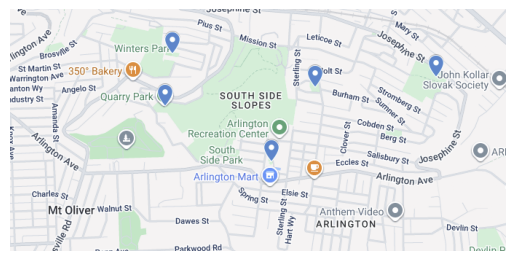

In [10]:
img = mpimg.imread("sss.png")
plt.imshow(img)
plt.axis("off")
plt.show()

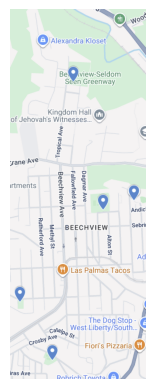

In [9]:
img = mpimg.imread("bv.png")
plt.imshow(img)
plt.axis("off")
plt.show()

The other two's neigborhoods are significantly closer to the playgrounds they claim to be near; Schenley Park is practically the same size as Squrirel Hill South and shouldn't claim the whole park as a part of the neigborhood if most if it is quite far from the neigborhood.

Let's assign scores based on number of playgrounds (n) out of a maximum of 5 (n/5):

In [11]:
pg_scores = count.copy()

count["score"] = count["playground_count"] / 5
count.loc[count["neighborhood"] == "Squirrel Hill South", "score"] = 2/5
count = count.sort_values("score", ascending=False)
print(count)

         neighborhood  playground_count  score
4           Beechview                 5    1.0
52  South Side Slopes                 5    1.0
0    Allegheny Center                 4    0.8
29      Highland Park                 4    0.8
5         Beltzhoover                 4    0.8
..                ...               ...    ...
62         Upper Hill                 1    0.2
64           West End                 1    0.2
65       West Oakland                 1    0.2
66           Westwood                 1    0.2
67            Windgap                 1    0.2

[68 rows x 3 columns]


Therefore, **Beechview and South Side Slopes** are the winners of this category: they both have 5 parks well within their actual community.

*Why is this important to consider?*

It's simple: because playgrounds are important for children. There are [numerous studies](https://pmc.ncbi.nlm.nih.gov/articles/PMC10718446/) that explain *why* they're just so important for children. Playgrounds do much more than just act as a place to entertain some little ones after school: they are a place where children can be active and social, often independently from their family.

### Do I agree with this result?

As discussed in the Master Notebook, **it is impossible to create a perfect score that would give you a 100% definitive answer as to what the "best" neighborhood truly is.** There are lots of things to consider: walkability, job availability/proximity to your job, the school district and zoning you are in, taxes, crime, traffic, flooding, proximity to points of interest (stores, favorite resturaunts, etc), and so on... and that's not mentioning things that you really can't measure, like aesthetics or "vibes." Moreover, playgrounds are kind of irrelavent to me at the moment... it's not like they're something I can really use. Thus, because numbers don't lie, I agree with this result. 

### So is this the same as my favorite neighborhood is? **NO!**

I've never set foot in Beechview a day in my life,  I don't recall ever visiting South Slide Slopes, and without further research, I have no idea what actually goes on in either. And honestly, *I don't have a favorite neigborhood*. I don't get to go out very often because I am caught up with so much stuff here on campus... nevermind the busywork I have recieved from all my nonsensical freshman classes this year. **BUT...** If you told me I HAD to pick a favorite neigborhood, it is East Liberty, as it is home to arguably *my all-time favorite pizzeria,* [Slice on Broadway](https://www.sliceonbroadway.com/). Although they have several locations around Pittsburgh, their East Liberty location is their closest, at least for biking or busing there. They have pizza that is good not just for Pittsburgh, Western PA, or even the East Coast as a whole... I would go as far to say that they are better than a majority of pizzerias in NYC*. 

It should go without saying that I have a different answer than what the data shows. *Why?* Because I am a human who cares more about intrensic properties than some conclusion drawn from some dataset. There is no dataset that shows the quality of pizza in Pittsburgh, though it would be funny if there were (and if there were, I would have picked it). 

****I was NOT paid to say any of this, but it would have been nice if they did!***